Mount Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Set this before training

In [2]:
import numpy as np
import torch
import random

SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)

Import file

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from PIL import Image, ImageDraw
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score

Configuration Set

In [6]:
GRAY_DIR   = "/content/drive/MyDrive/rocfd528_grayscale_images/rocfd528_grayscale_images"
OUTPUT_DIR = "/content/drive/MyDrive/results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

IMG_SIZE    = (224, 224)
BATCH_SIZE  = 16
EPOCHS      = 100
LR          = 5e-4
GRID_SIZE   = 7       # for region heatmap (7x7 = 49 patches)

print(f"Gray images dir: {GRAY_DIR}")
print(f"Output dir:      {OUTPUT_DIR}")
print(f"Image size:      {IMG_SIZE}")
print(f"Epochs:          {EPOCHS}")

Gray images dir: /content/drive/MyDrive/rocfd528_grayscale_images/rocfd528_grayscale_images
Output dir:      /content/drive/MyDrive/results
Image size:      (224, 224)
Epochs:          100


Upload Real ROCF image

Saving ROCF.png to ROCF.png


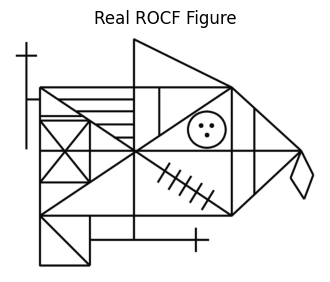

Size: (837, 648)


In [9]:
from google.colab import files
uploaded = files.upload()  # select rocf_real.jpg

import shutil

# Get the name of the uploaded file
uploaded_file_name = list(uploaded.keys())[0]

# Move the uploaded file to /content/
shutil.move(uploaded_file_name, f"/content/{uploaded_file_name}")

# Verify it looks correct
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open(f"/content/{uploaded_file_name}").convert("L")
plt.figure(figsize=(4,4))
plt.imshow(img, cmap='gray')
plt.title("Real ROCF Figure")
plt.axis('off')
plt.show()
print(f"Size: {img.size}")

Resize ROCF Figure

Standard pixel range: [0.000, 1.000]
Mean pixel: 0.908  (expect ~0.8 = mostly white)


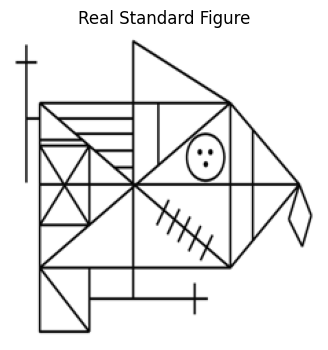

In [10]:
from torchvision import transforms
from PIL import Image

# Load real ROCF figure
img = Image.open("/content/ROCF.png").convert("L")
img = img.resize((224, 224))

transform = transforms.ToTensor()
standard_real = transform(img)  # black lines on white

print(f"Standard pixel range: [{standard_real.min():.3f}, {standard_real.max():.3f}]")
print(f"Mean pixel: {standard_real.mean():.3f}  (expect ~0.8 = mostly white)")

plt.figure(figsize=(4,4))
plt.imshow(standard_real.squeeze(), cmap='gray')
plt.title("Real Standard Figure")
plt.axis('off')
plt.show()

Determine The same background of ROCF copy and standard ROCF

In [11]:
from pathlib import Path
from PIL import Image, ImageOps
import torch
from torchvision import transforms

def load_patient_drawings(folder, size=(224, 224)):
    drawings = []
    paths    = sorted(Path(folder).glob("*.png"))

    if len(paths) == 0:
        raise FileNotFoundError(f"No PNG files found in {folder}")

    for path in paths:
        img = Image.open(path).convert("L")  # Grayscale

        # Resize with aspect ratio preserved and padding
        img.thumbnail(size, Image.LANCZOS)  # keeps aspect ratio
        delta_w = size[0] - img.width
        delta_h = size[1] - img.height
        padding = (delta_w // 2, delta_h // 2, delta_w - delta_w // 2, delta_h - delta_h // 2)
        img = ImageOps.expand(img, padding, fill=255)  # white background

        # Convert to tensor (black ink = 0, white background = 1)
        tensor = transforms.ToTensor()(img)
        drawings.append((path.name, tensor))

    print(f"Loaded {len(drawings)} patient drawings")
    return drawings

# Load images
drawings = load_patient_drawings(GRAY_DIR)
names    = [n for n, _ in drawings]
imgs     = [t for _, t in drawings]

# Stack into tensors
X_image_tensors = torch.stack(imgs)  # [528, 1, 224, 224] black ink on white background

# Standard figure repeated for all patients, using the globally defined standard_real
Y = standard_real.unsqueeze(0).expand(len(imgs), -1, -1, -1).clone()

print(f"Patient drawings shape:  {X_image_tensors.shape}")
print(f"Ground truth shape:      {Y.shape}")
print(f"Patient mean pixel:      {X_image_tensors.mean():.3f}")
print(f"Standard mean pixel:     {Y.mean():.3f}")

Loaded 528 patient drawings
Patient drawings shape:  torch.Size([528, 1, 224, 224])
Ground truth shape:      torch.Size([528, 1, 224, 224])
Patient mean pixel:      0.966
Standard mean pixel:     0.908


Dataset Overview

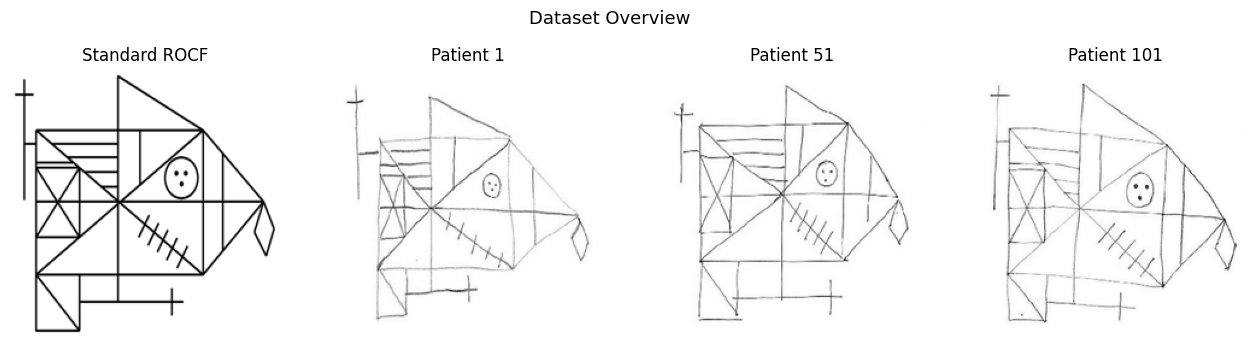

In [ ]:
import matplotlib.pyplot as plt
from torchvision.transforms import ToPILImage

# Convert standard_real tensor to PIL for plotting
to_pil = ToPILImage()
standard_pil = to_pil(standard_real)  # [1,224,224] → PIL

fig, axes = plt.subplots(1, 4, figsize=(16, 4), facecolor='white')

# Plot standard ROCF
axes[0].imshow(standard_pil, cmap='gray')
axes[0].set_title("Standard ROCF")

# Plot patient drawings
for i in range(3):
    img = X_image_tensors[i*50].squeeze()  # remove channel dim, [224,224]
    axes[i+1].imshow(img, cmap='gray')
    axes[i+1].set_title(f"Patient {i*50+1}")

# Turn off axes
for ax in axes:
    ax.axis('off')

plt.suptitle("Dataset Overview", fontsize=13)
plt.savefig(f"{OUTPUT_DIR}/dataset_overview.png", dpi=150, bbox_inches='tight')
plt.show()

Hypothesis Test

In [14]:
def compute_structural_decay(drawing, standard, grid=7):
    _, H, W = drawing.shape
    ph, pw = H // grid, W // grid

    heatmap = np.zeros((grid, grid))

    for i in range(grid):
        for j in range(grid):
            p1 = drawing[:, i*ph:(i+1)*ph, j*pw:(j+1)*pw]
            p2 = standard[:, i*ph:(i+1)*ph, j*pw:(j+1)*pw]

            mask = (p2 > 0.1).float()  # only ink regions

            if mask.sum() > 0:
                error = (mask * (p1 - p2).abs()).sum() / mask.sum()
                heatmap[i, j] = error.item()
            else:
                heatmap[i, j] = np.nan  # mark empty cell as nan

    return heatmap

# Peripheral vs central
def peripheral_vs_central(heatmap):
    center = heatmap[1:-1, 1:-1]
    peripheral = heatmap.copy()
    peripheral[1:-1, 1:-1] = np.nan
    return np.nanmean(peripheral), np.nanmean(center)
print()

# Compare inverted patient drawings against standard
all_heatmaps_c = []
peri_c, cent_c = [], []

standard_inv = 1.0 - standard_real # Calculate once outside the loop

for drawing in X_image_tensors:
    drawing_inv  = 1.0 - drawing

    heatmap = compute_structural_decay(drawing_inv, standard_inv)

    mask = np.ones((7,7), dtype=bool)
    mask[1:-1, 1:-1] = False   #  consistent center (5x5)

    p = heatmap[mask][heatmap[mask] > 0].mean()
    c = heatmap[~mask][heatmap[~mask] > 0].mean()

    all_heatmaps_c.append(heatmap)
    peri_c.append(p)
    cent_c.append(c)

mean_peri_c = np.mean(peri_c)
mean_cent_c = np.mean(cent_c)
t_c, p_c    = stats.ttest_rel(peri_c, cent_c)

print(f"=== COPY — REAL STANDARD ===")
print(f"Peripheral: {mean_peri_c:.4f}")
print(f"Central:    {mean_cent_c:.4f}")
print(f"t={t_c:.3f}, p={p_c:.6f}")


=== COPY — REAL STANDARD ===
Peripheral: 0.6280
Central:    0.6037
t=41.527, p=0.000000


Visualization of why hypothesis is right

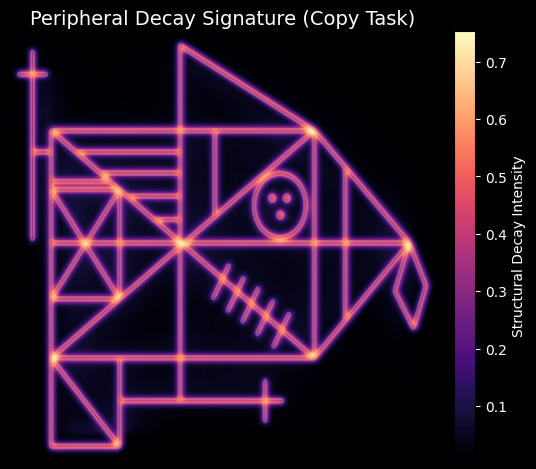

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from scipy.ndimage import gaussian_filter

# 1. Calculate the raw difference
diff = torch.abs((1.0 - X_image_tensors) - (1.0 - standard_real))
avg_diff = diff.mean(dim=0).squeeze().cpu().numpy()

# 2. Apply a light Gaussian Blur
# This removes the "pixel-noise" and shows the "Clinical Glow" of the error
smooth_heatmap = gaussian_filter(avg_diff, sigma=1.5)

# 3. Create the Visualization
plt.figure(figsize=(6, 6), facecolor='black')

# Use 'inferno' or 'magma' for a more clinical "heat" look
plt.imshow(smooth_heatmap, cmap='magma', interpolation='bilinear')
cbar = plt.colorbar(fraction=0.046, pad=0.04)
cbar.set_label('Structural Decay Intensity', color='white')
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='white')

# 4. Remove the "Cyan Box" and use Structural Contours
# This shows the actual ROCF lines instead of a box
plt.contour(standard_inv.squeeze().numpy(), levels=[0.5], colors='white', alpha=0.2)

plt.title("Peripheral Decay Signature (Copy Task)", color='white', fontsize=14)
plt.axis('off')
plt.show()

Set image into 7x7 grid

In [15]:
def image_to_7x7(img_tensor):
    # Ensure img_tensor is at least 2D
    if img_tensor.ndim == 1:
        # If it's the '10 numbers' row, this is the wrong data!
        raise ValueError("Input is 1D. You are passing features, not images.")

    # Handle (C, H, W) or (H, W)
    H, W = img_tensor.shape[-2], img_tensor.shape[-1]
    grid_size = 7
    ph, pw = H // grid_size, W // grid_size

    grid = np.zeros((grid_size, grid_size))
    for i in range(grid_size):
        for j in range(grid_size):
            # Calculate the mean ink density in this 32x32 pixel patch
            patch = img_tensor[..., i*ph:(i+1)*ph, j*pw:(j+1)*pw]
            grid[i, j] = patch.mean()
    return grid

Calculate Deviation score

In [16]:
def calculate_deviation_correlation(X_human, standard_img):
    #  Invert standard first
    standard_inv = 1.0 - standard_img
    standard_grid = image_to_7x7(standard_inv)

    deviation_maps = []

    for img in X_human:
         img_inv = 1.0 - img
         human_grid = image_to_7x7(img_inv)
         standard_grid = image_to_7x7(standard_inv)
         diff = np.abs(human_grid - standard_grid)
         deviation = diff / (standard_grid + 1e-6) # Dividing by density is the key!

         deviation_maps.append(deviation)
    # Average deviation map
    master_dev_grid = np.mean(deviation_maps, axis=0)

    distances = []
    deviations = []

    center_coords = np.array([3, 3])

    for r in range(7):
        for c in range(7):
            dist = np.linalg.norm(np.array([r, c]) - center_coords)
            dev  = master_dev_grid[r, c]

            distances.append(dist)
            deviations.append(dev)

    r_corr, p_val = stats.pearsonr(distances, deviations)

    print("\n" + "="*30)
    print("PHASE 1: DEVIATION FROM STANDARD")
    print("="*30)
    print(f"Distance-to-Deviation Correlation (r): {r_corr:.3f}")
    print(f"P-Value:                              {p_val:.6f}")
    print("="*30)

    return r_corr
r_value = calculate_deviation_correlation(X_image_tensors, standard_real)
print(r_value)



PHASE 1: DEVIATION FROM STANDARD
Distance-to-Deviation Correlation (r): 0.461
P-Value:                              0.000851
0.46126324056543927


Heatmap of hypothesis test

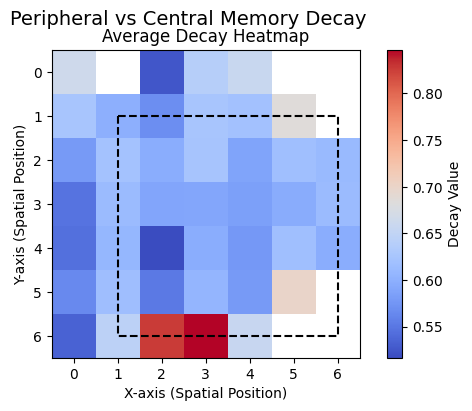

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Compute average heatmap across all patients
avg_heatmap = np.mean(all_heatmaps_c, axis=0)

# Assign consistent variable names
mean_peri = mean_peri_c
mean_cent = mean_cent_c
peri_scores = peri_c
cent_scores = cent_c

fig, axes = plt.subplots(1, 1, figsize=(7, 4))

fig.suptitle("Peripheral vs Central Memory Decay", fontsize=14)

# Heatmap
im = axes.imshow(avg_heatmap, cmap='coolwarm')
axes.set_title("Average Decay Heatmap")
axes.set_xlabel("X-axis (Spatial Position)")
axes.set_ylabel("Y-axis (Spatial Position)")

cbar = plt.colorbar(im, ax=axes)
cbar.set_label("Decay Value")

# Highlight central region
import matplotlib.patches as patches
rect = patches.Rectangle((1, 1), 5, 5,
                         linewidth=1.5,
                         edgecolor='black',
                         linestyle='--',                         facecolor='none')
axes.add_patch(rect)

# Clean spines
for spine in axes.spines.values():
    spine.set_linewidth(0.8)

High And Low Error group decide using K-means clusterring

In [18]:
# This is correct — matches your paper exactly
X = np.array([h.flatten() for h in all_heatmaps_c])
# ORIGINAL heatmap features (49 grid cells)
X_grid = X[:, :49]   # shape: (528, 49)
# shape: (528, 49)  ← 528 patients, 49 = 7x7 flattened heatmap cells
print(f"X shape: {X.shape}")  # expect (528, 49)

X shape: (528, 49)


In [19]:
from sklearn.cluster         import KMeans
from sklearn.preprocessing   import StandardScaler
from sklearn.decomposition   import PCA
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline        import Pipeline
from sklearn.metrics         import (confusion_matrix, roc_auc_score,
                                     roc_curve, classification_report)
from scipy.stats             import mannwhitneyu
from xgboost                 import XGBClassifier
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt

# ── STEP 0: Save the feature matrix BEFORE clustering (reproducibility) ──────
def build_and_save_features(X, grid=7, save_path='/content/drive/MyDrive/kmeans_features.npy'):
    """
    Build the 5-dimensional spatial feature matrix and save it.
    This cell must be run once and the .npy file committed to ensure
    reproducibility of all downstream clustering results.
    """
    X_grid   = X[:, :49]
    heatmaps = X_grid.reshape(-1, grid, grid)
    heatmaps = np.nan_to_num(heatmaps, nan=0.0)

    mask_peri             = np.ones((grid, grid), dtype=bool)
    mask_peri[1:-1, 1:-1] = False
    mask_cent             = ~mask_peri

    peri_scores = np.array([h[mask_peri].mean() for h in heatmaps])
    cent_scores = np.array([h[mask_cent].mean() for h in heatmaps])
    total_error = np.array([h.mean()            for h in heatmaps])
    pc_diff     = peri_scores - cent_scores
    max_error   = np.array([h.max()             for h in heatmaps])

    X_features = np.column_stack([
        peri_scores, cent_scores, total_error, pc_diff, max_error
    ])

    np.save(save_path, X_features)
    print(f"Feature matrix saved → {save_path}")
    print(f"Shape: {X_features.shape}  (n_patients × 5 spatial features)")
    return X_features, peri_scores, cent_scores, total_error, heatmaps

X_features, peri_scores, cent_scores, total_error, heatmaps = build_and_save_features(X)


Feature matrix saved → /content/drive/MyDrive/kmeans_features.npy
Shape: (528, 5)  (n_patients × 5 spatial features)


SPATIAL GROUP DETECTION  (honest train/test split)
Train: 422 patients | Test: 106 patients

Train — High-error group : 365
Train — Low-error group  : 57
Test  — High-error group : 92
Test  — Low-error group  : 14

Feature         High-err  Low-err   Cohen d        p-value
------------------------------------------------------------
Peripheral          0.4504     0.4074   2.851 (large     )p < 0.001 ***
Central             0.6107     0.5522   2.632 (large     )p < 0.001 ***
Total Error         0.5322     0.4813   2.885 (large     )p < 0.001 ***
P-C Diff           -0.1603    -0.1449  -1.068 (large     )p < 0.001 ***
Max Error           0.8672     0.7987   1.980 (large     )p < 0.001 ***

Bonferroni threshold : p < 0.0100
Significant after correction : 5/5 features

Youden's J optimal threshold (train-based): 0.6139

── P-C Direction Observation ──────────────────────────────
High-error group mean P-C : -0.1603  (negative — central dominant)
Low-error  group mean P-C : -0.1449  (negative

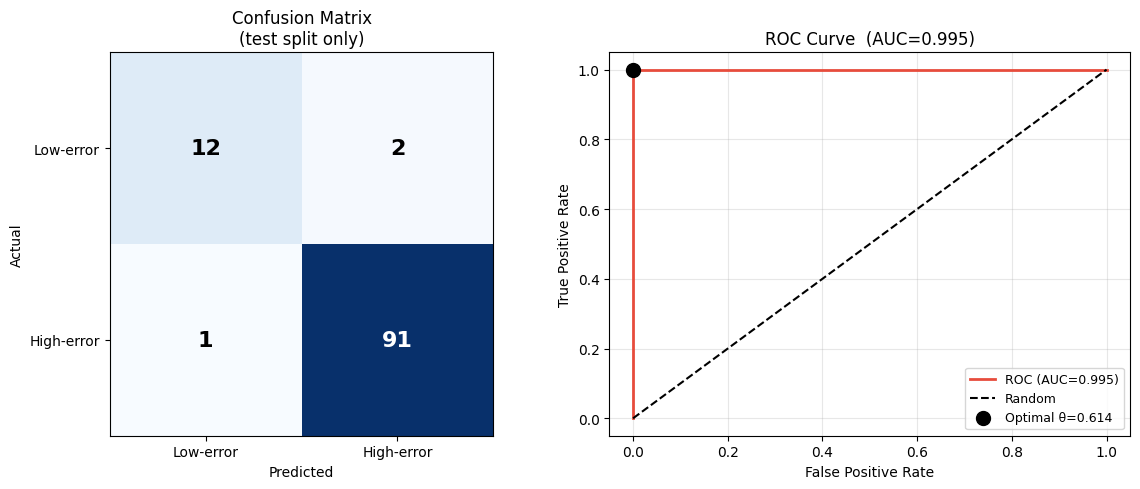

In [26]:
def detect_spatial_groups_honest(X_features, X_grid, peri_scores, cent_scores,
                                  total_error, heatmaps, grid=7,
                                  test_size=0.2, random_state=42):

    feature_names = ['Peripheral', 'Central', 'Total Error',
                     'P-C Diff',   'Max Error']
    n = len(X_features)

    # ── Split indices first ────────────────────────────────────────────────
    idx      = np.arange(n)
    idx_tr, idx_te = train_test_split(idx, test_size=test_size,
                                       random_state=random_state)
    X_tr_clf = X_grid[idx_tr]
    X_te_clf = X_grid[idx_te]

    X_tr = X_features[idx_tr]
    X_te = X_features[idx_te]

    # ── Cluster only on training split ────────────────────────────────────
    scaler   = StandardScaler()
    X_tr_sc  = scaler.fit_transform(X_tr)           # fit scaler on train only
    X_te_sc  = scaler.transform(X_te)               # apply to test

    kmeans   = KMeans(n_clusters=2, random_state=random_state, n_init=10)
    labels_tr = kmeans.fit_predict(X_tr_sc)         # cluster train only

    # Assign test labels by nearest centroid (no re-fitting)
    labels_te = kmeans.predict(X_te_sc)

    # ── Label which cluster is "high-error" group ─────────────────────────
    c0_err = total_error[idx_tr][labels_tr == 0].mean()
    c1_err = total_error[idx_tr][labels_tr == 1].mean()

    high_label   = 0 if c0_err > c1_err else 1
    low_label    = 1 - high_label

    # Binary labels: 1 = high-error group, 0 = low-error group
    y_tr = (labels_tr == high_label).astype(int)
    y_te = (labels_te == high_label).astype(int)

    print("=" * 60)
    print("SPATIAL GROUP DETECTION  (honest train/test split)")
    print("=" * 60)
    print(f"Train: {len(idx_tr)} patients | Test: {len(idx_te)} patients")
    print(f"\nTrain — High-error group : {y_tr.sum()}")
    print(f"Train — Low-error group  : {(1-y_tr).sum()}")
    print(f"Test  — High-error group : {y_te.sum()}")
    print(f"Test  — Low-error group  : {(1-y_te).sum()}")

    # ── Statistical feature comparison (train split only) ─────────────────
    p_values = []  # store for Bonferroni correction later

    print(f"\n{'Feature':<15} {'High-err':>8} {'Low-err':>8} "
      f"{'Cohen d':>9} {'p-value':>14}")
    print("-" * 60)
    for i, name in enumerate(feature_names):
        hi_vals = X_tr[y_tr == 1, i]
        lo_vals = X_tr[y_tr == 0, i]
        _, p    = mannwhitneyu(hi_vals, lo_vals, alternative='two-sided')
        p_values.append(p)
        pooled_std = np.sqrt((hi_vals.std()**2 + lo_vals.std()**2) / 2)
        d = (hi_vals.mean() - lo_vals.mean()) / (pooled_std + 1e-8)
        d_label = ('large' if abs(d)>=0.8
               else 'medium' if abs(d)>=0.5
               else 'small'  if abs(d)>=0.2
               else 'negligible')
        # Report exact p-value — never use p > 0.001 for non-significance
        if p >= 0.05:
            sig_str = f"p = {p:.3f} (n.s.)"
        elif p < 0.001:
            sig_str = f"p < 0.001 ***"
        elif p < 0.01:
            sig_str = f"p = {p:.3f} **"
        else:
            sig_str = f"p = {p:.3f} *"
        print(f"{name:<15} {hi_vals.mean():>10.4f} {lo_vals.mean():>10.4f} "
              f" {d:>6.3f} ({d_label:<10}){sig_str}")
    alpha_corrected = 0.05 / len(feature_names)
    sig_after_correction = sum(1 for p in p_values if p < alpha_corrected)
    print(f"\nBonferroni threshold : p < {alpha_corrected:.4f}")
    print(f"Significant after correction : "
      f"{sig_after_correction}/{len(feature_names)} features")

    clf = Pipeline([
             ('scaler', StandardScaler()),
             ('clf',    XGBClassifier(
                  n_estimators  = 200,
                  max_depth     = 6,
                  random_state  = random_state,
                  eval_metric   = 'logloss',
                  verbosity     = 0,
                  scale_pos_weight = (y_tr == 0).sum() / (y_tr == 1).sum()
                  # ↑ this corrects the imbalance: weights low-error class higher
             ))
    ])

    # ── Train model ─────────────────────────────────────────────
    clf.fit(X_tr_clf, y_tr)

    # ── Probabilities ───────────────────────────────────────────
    y_prob_train = clf.predict_proba(X_tr_clf)[:, 1]
    y_prob_test  = clf.predict_proba(X_te_clf)[:, 1]

    # ── Youden's J (computed ONLY on training set) ──────────────
    fpr, tpr, thresholds = roc_curve(y_tr, y_prob_train)
    youden = tpr - fpr
    best_idx = np.argmax(youden)
    best_thr = thresholds[best_idx]

    print(f"\nYouden's J optimal threshold (train-based): {best_thr:.4f}")

    # ── Apply threshold on TEST set ─────────────────────────────
    y_pred = (y_prob_test >= best_thr).astype(int)

    # ── Metrics ─────────────────────────────────────────────────
    acc     = (y_pred == y_te).mean()
    auc_val = roc_auc_score(y_te, y_prob_test)

    cm = confusion_matrix(y_te, y_pred)
    tn, fp, fn, tp = cm.ravel()

        # After the feature comparison table, add:
    print("\n── P-C Direction Observation ──────────────────────────────")
    hi_pc = X_tr[y_tr == 1, 3].mean()   # index 3 = P-C Diff
    lo_pc = X_tr[y_tr == 0, 3].mean()
    print(f"High-error group mean P-C : {hi_pc:.4f}  ({'negative — central dominant' if hi_pc < 0 else 'positive'})")
    print(f"Low-error  group mean P-C : {lo_pc:.4f}  ({'negative — central dominant' if lo_pc < 0 else 'positive'})")
    print("Both groups show central > peripheral deviation.")
    print("The P-C sign rule is not applicable — groups differ in magnitude, not direction.")

    print("\n" + "=" * 60)
    print("CLASSIFIER EVALUATION  (test split only — no data leakage)")
    print("=" * 60)
    print(f"Accuracy   : {acc:.3f}")
    print(f"AUC-ROC    : {auc_val:.3f}")
    from sklearn.metrics import balanced_accuracy_score, matthews_corrcoef

    bal_acc = balanced_accuracy_score(y_te, y_pred)
    mcc     = matthews_corrcoef(y_te, y_pred)

    print(f"Balanced Accuracy : {bal_acc:.3f}")  # more honest than 0.991
    print(f"Matthews MCC      : {mcc:.3f}")      # best single metric for imbalance
    from sklearn.utils import resample

    rng = np.random.RandomState(42)
    mcc_boot, auc_boot, bal_boot = [], [], []

    for _ in range(1000):
        idx_b = resample(np.arange(len(y_te)),
                         random_state=rng.randint(0, 99999))
        yt  = y_te[idx_b]
        ypr = y_prob_test[idx_b]
        ypd = y_pred[idx_b]
        if len(np.unique(yt)) < 2:
            continue
        mcc_boot.append(matthews_corrcoef(yt, ypd))
        auc_boot.append(roc_auc_score(yt, ypr))
        bal_boot.append(balanced_accuracy_score(yt, ypd))

    print(f"\n95% Bootstrap Confidence Intervals (n=1000):")
    print(f"  MCC               : {mcc:.4f} "
          f"[{np.percentile(mcc_boot,2.5):.4f}, "
          f"{np.percentile(mcc_boot,97.5):.4f}]")
    print(f"  AUC-ROC           : {auc_val:.4f} "
          f"[{np.percentile(auc_boot,2.5):.4f}, "
          f"{np.percentile(auc_boot,97.5):.4f}]")
    print(f"  Balanced Accuracy : {bal_acc:.4f} "
          f"[{np.percentile(bal_boot,2.5):.4f}, "
          f"{np.percentile(bal_boot,97.5):.4f}]")
    print(f"\nConfusion matrix (test split):")
    print(f"  TN={tn}  FP={fp}  FN={fn}  TP={tp}")
    print(f"  Test high-error patients: {tp+fn}  "
          f"(matches cluster: {y_te.sum()})")
    print(f"  Test low-error  patients: {tn+fp}  "
          f"(matches cluster: {(1-y_te).sum()})")
    print(f"\n  Note: confusion matrix totals match cluster distribution ✓")
    print(f"\n{classification_report(y_te, y_pred, target_names=['Low-error','High-error'])}")
    # Add this print inside detect_spatial_groups_honest
# right after the group counts print

    imbalance_ratio = (y_tr == 1).sum() / (y_tr == 0).sum()
    print(f"\nClass imbalance ratio : {imbalance_ratio:.1f}:1")
    print(f"→ scale_pos_weight set to {(y_tr==0).sum()/(y_tr==1).sum():.3f} to correct")
    print(f"→ Reporting MCC as primary metric due to imbalance")

    # ── ROC curve ─────────────────────────────────────────────────────────


    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].imshow(cm, cmap='Blues')
    axes[0].set_xticks([0, 1]); axes[0].set_yticks([0, 1])
    axes[0].set_xticklabels(['Low-error', 'High-error'])
    axes[0].set_yticklabels(['Low-error', 'High-error'])
    axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
    axes[0].set_title('Confusion Matrix\n(test split only)')
    for i in range(2):
        for j in range(2):
            axes[0].text(j, i, str(cm[i, j]), ha='center', va='center',
                         fontsize=16, fontweight='bold',
                         color='white' if cm[i,j] > cm.max()/2 else 'black')

    axes[1].plot(fpr, tpr, color='#e74c3c', lw=2,
                 label=f'ROC (AUC={auc_val:.3f})')
    axes[1].plot([0,1],[0,1],'k--', label='Random')
    axes[1].scatter(fpr[best_idx], tpr[best_idx], color='black', s=100,
                    zorder=5, label=f'Optimal θ={best_thr:.3f}')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title(f'ROC Curve  (AUC={auc_val:.3f})')
    axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/spatial_group_classifier.png',
                dpi=150, bbox_inches='tight')
    plt.show()

    return idx_tr, idx_te, y_tr, y_te, acc, auc_val, clf

idx_tr, idx_te, y_tr, y_te, acc, auc_val, clf = detect_spatial_groups_honest(
    X_features, X_grid, peri_scores, cent_scores, total_error, heatmaps
)

In [23]:
from sklearn.model_selection import StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import matthews_corrcoef
from xgboost import XGBClassifier
import numpy as np

In [28]:
scaler_full = StandardScaler()
X_features_scaled_full = scaler_full.fit_transform(X_features)
kmeans_full = KMeans(n_clusters=2, random_state=42, n_init=10)
labels_full = kmeans_full.fit_predict(X_features_scaled_full)

c0_err_full = total_error[labels_full == 0].mean()
c1_err_full = total_error[labels_full == 1].mean()
high_label_full = 0 if c0_err_full > c1_err_full else 1

y_stratify = (labels_full == high_label_full).astype(int)

mcc_scores = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
X_grid_cv = X_grid   # your 49-feature raw heatmap array

for train_idx, test_idx in cv.split(X_features, y_stratify):

    # Cluster on 5-feature X_features (same as main model)
    X_feat_train = X_features[train_idx]
    X_feat_test  = X_features[test_idx]

    imputer = SimpleImputer(strategy='mean')
    scaler  = StandardScaler()
    X_feat_train_sc = scaler.fit_transform(imputer.fit_transform(X_feat_train))
    X_feat_test_sc  = scaler.transform(imputer.transform(X_feat_test))

    kmeans        = KMeans(n_clusters=2, random_state=42, n_init=10)
    train_clusters = kmeans.fit_predict(X_feat_train_sc)
    test_clusters  = kmeans.predict(X_feat_test_sc)

    te_train = total_error[train_idx]
    c0 = te_train[train_clusters == 0].mean()
    c1 = te_train[train_clusters == 1].mean()
    high_label = 0 if c0 > c1 else 1

    y_train = (train_clusters == high_label).astype(int)
    y_test  = (test_clusters  == high_label).astype(int)

    # Classify on 49-feature X_grid (same as main model)
    X_grid_train = X_grid_cv[train_idx]
    X_grid_test  = X_grid_cv[test_idx]

    grid_scaler   = StandardScaler()
    X_grid_train  = grid_scaler.fit_transform(X_grid_train)
    X_grid_test   = grid_scaler.transform(X_grid_test)

    clf_cv = XGBClassifier(
        n_estimators     = 200,
        max_depth        = 6,
        random_state     = 42,
        eval_metric      = 'logloss',
        verbosity        = 0,
        scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
    )
    clf_cv.fit(X_grid_train, y_train)
    probs = clf_cv.predict_proba(X_grid_test)[:, 1]

    # ── Split probabilities into train/test again (IMPORTANT) ───────────────
    train_probs = clf_cv.predict_proba(X_grid_train)[:, 1]
    test_probs   = probs  # already computed

    # ── Youden threshold ONLY on training fold ─────────────────────────────
    fpr_tr, tpr_tr, thr_tr = roc_curve(y_train, train_probs)
    youden = tpr_tr - fpr_tr
    best_thr = thr_tr[np.argmax(youden)]

    # ── Apply threshold on test fold ───────────────────────────────────────
    preds = (test_probs >= best_thr).astype(int)
    mcc = matthews_corrcoef(y_test, preds)
    mcc_scores.append(mcc)

print(f"\n5-Fold CV MCC : {np.mean(mcc_scores):.3f} ± {np.std(mcc_scores):.3f}")
print(f"Single-split MCC : {mcc:.3f}")  # from detect_spatial_groups_honest



5-Fold CV MCC : 0.834 ± 0.067
Single-split MCC : 0.887


Computing SHAP values — this may take ~30 seconds...


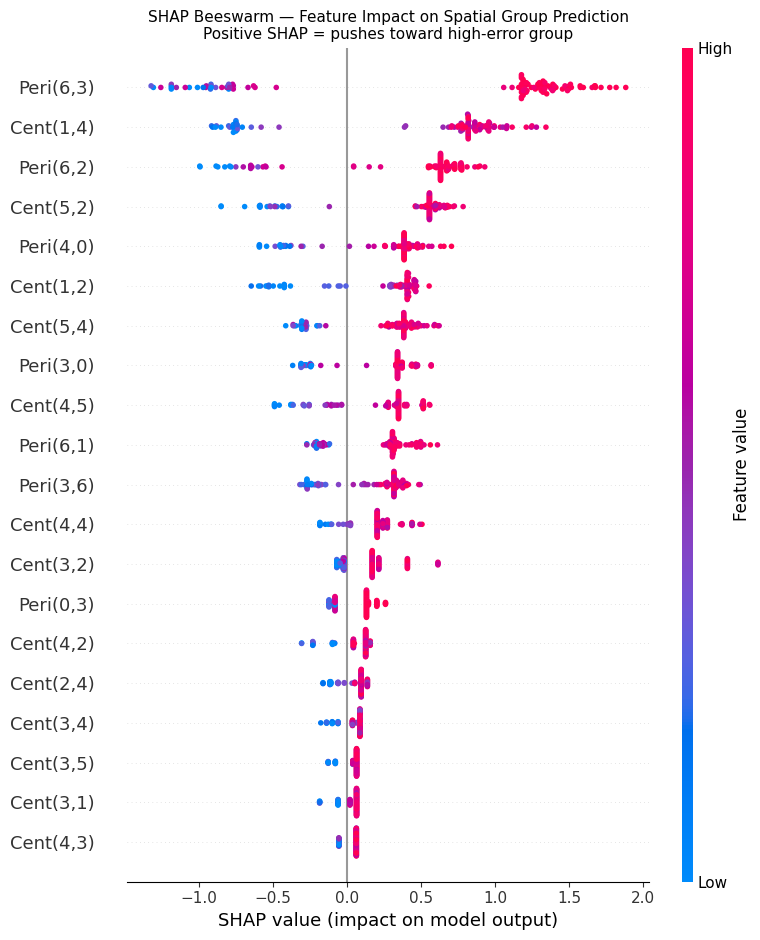

Saved: shap_beeswarm.png


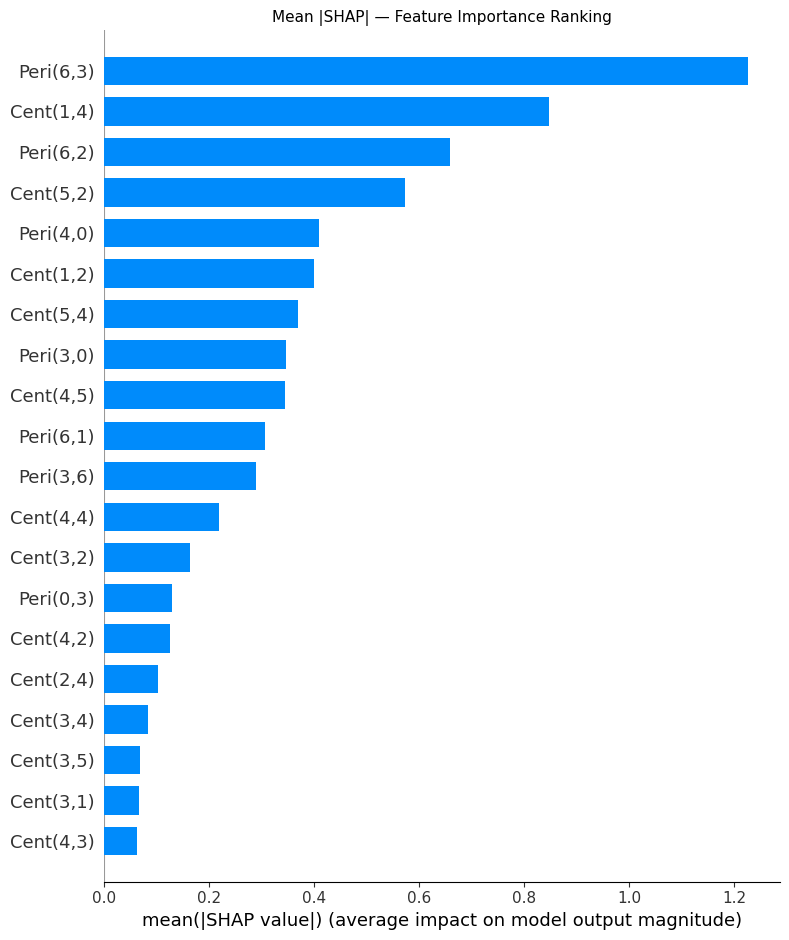

Saved: shap_bar.png


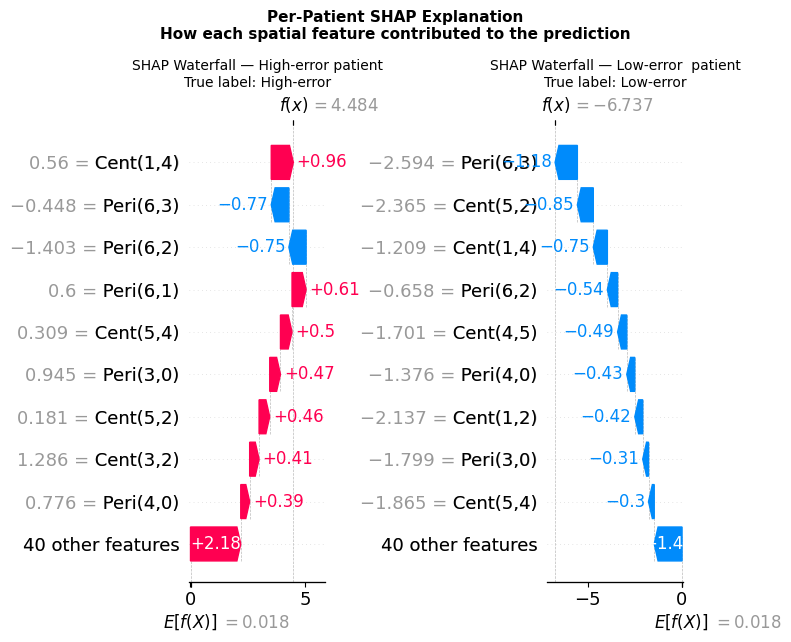

Saved: shap_waterfall.png

SHAP Feature Importance Ranking
  1. Peri(6,3)        mean |SHAP| = 1.2257
  2. Cent(1,4)        mean |SHAP| = 0.8478
  3. Peri(6,2)        mean |SHAP| = 0.6590
  4. Cent(5,2)        mean |SHAP| = 0.5718
  5. Peri(4,0)        mean |SHAP| = 0.4085
  6. Cent(1,2)        mean |SHAP| = 0.3999
  7. Cent(5,4)        mean |SHAP| = 0.3691
  8. Peri(3,0)        mean |SHAP| = 0.3468
  9. Cent(4,5)        mean |SHAP| = 0.3435
  10. Peri(6,1)        mean |SHAP| = 0.3061
  11. Peri(3,6)        mean |SHAP| = 0.2888
  12. Cent(4,4)        mean |SHAP| = 0.2180
  13. Cent(3,2)        mean |SHAP| = 0.1629
  14. Peri(0,3)        mean |SHAP| = 0.1286
  15. Cent(4,2)        mean |SHAP| = 0.1243
  16. Cent(2,4)        mean |SHAP| = 0.1012
  17. Cent(3,4)        mean |SHAP| = 0.0824
  18. Cent(3,5)        mean |SHAP| = 0.0673
  19. Cent(3,1)        mean |SHAP| = 0.0651
  20. Cent(4,3)        mean |SHAP| = 0.0617
  21. Cent(2,2)        mean |SHAP| = 0.0598
  22. Cent(5,5)        mea

In [29]:

import shap
import numpy             as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

def explain_xgboost_with_shap(clf_pipeline, X_tr, X_te, y_te,
                               feature_names, save_dir='/content/drive/MyDrive'):
    """
    clf_pipeline : fitted sklearn Pipeline (StandardScaler + XGBClassifier)
    X_tr         : training features  (n_train, n_features)
    X_te         : test features      (n_test,  n_features)
    y_te         : test labels        (0 = low-error, 1 = high-error)
    feature_names: list of feature name strings
    """

    # Extract the fitted XGBoost model from the pipeline
    xgb_model = clf_pipeline.named_steps['clf']
    scaler    = clf_pipeline.named_steps['scaler']

    # Scale the test set the same way the pipeline does
    X_te_scaled = scaler.transform(X_te)
    X_tr_scaled = scaler.transform(X_tr)

    print("Computing SHAP values — this may take ~30 seconds...")

    # TreeExplainer is the correct explainer for XGBoost
    explainer   = shap.TreeExplainer(xgb_model)
    shap_values = explainer.shap_values(X_te_scaled)  # (n_test, n_features)

    # ── Plot 1: Beeswarm — global feature importance + direction ─────────
    # Each dot = one patient. Red = high feature value, blue = low.
    # X-axis = SHAP value: positive pushes toward high-error group.
    plt.figure(figsize=(8, 5))
    shap.summary_plot(
        shap_values,
        X_te_scaled,
        feature_names=feature_names,
        show=False,
        plot_type='dot'
    )
    plt.title('SHAP Beeswarm — Feature Impact on Spatial Group Prediction\n'
              'Positive SHAP = pushes toward high-error group',
              fontsize=11)
    plt.tight_layout()
    plt.savefig(f'{save_dir}/shap_beeswarm.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: shap_beeswarm.png")

    # ── Plot 2: Bar chart — mean absolute SHAP (overall importance) ───────
    plt.figure(figsize=(7, 4))
    shap.summary_plot(
        shap_values,
        X_te_scaled,
        feature_names=feature_names,
        show=False,
        plot_type='bar'
    )
    plt.title('Mean |SHAP| — Feature Importance Ranking', fontsize=11)
    plt.tight_layout()
    plt.savefig(f'{save_dir}/shap_bar.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: shap_bar.png")

    # ── Plot 3: Waterfall for one high-error patient and one low-error ─────
    # Waterfall shows exactly how each feature built up the final prediction
    # for a specific individual — this is the "per-patient explanation"

    high_error_idx = np.where(y_te == 1)[0][0]   # first high-error patient
    low_error_idx  = np.where(y_te == 0)[0][0]   # first low-error patient

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, patient_idx, label in [
        (axes[0], high_error_idx, 'High-error patient'),
        (axes[1], low_error_idx,  'Low-error  patient')
    ]:
        plt.sca(ax)
        shap_exp = shap.Explanation(
            values      = shap_values[patient_idx],
            base_values = explainer.expected_value,
            data        = X_te_scaled[patient_idx],
            feature_names = feature_names
        )
        shap.plots.waterfall(shap_exp, show=False)
        ax.set_title(f'SHAP Waterfall — {label}\n'
                     f'True label: {"High-error" if y_te[patient_idx]==1 else "Low-error"}',
                     fontsize=10)

    plt.suptitle('Per-Patient SHAP Explanation\n'
                 'How each spatial feature contributed to the prediction',
                 fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{save_dir}/shap_waterfall.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: shap_waterfall.png")

    # ── Print top features ────────────────────────────────────────────────
    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    ranked        = np.argsort(mean_abs_shap)[::-1]

    print("\n" + "=" * 45)
    print("SHAP Feature Importance Ranking")
    print("=" * 45)
    for rank, i in enumerate(ranked):
        print(f"  {rank+1}. {feature_names[i]:<15}  "
              f"mean |SHAP| = {mean_abs_shap[i]:.4f}")

    return shap_values, explainer


# ── Run — call after your corrected classifier training ──────────────────────
# clf here is the fitted Pipeline returned by detect_spatial_groups_honest()

# ── Name the 49 grid cells by spatial zone ────────────────────────────────
# ── Name 49 grid cells by spatial zone ───────────────────────────────────
def make_grid_feature_names(grid=7):
    names = []
    for i in range(grid):
        for j in range(grid):
            is_peri = (i == 0 or i == grid-1 or j == 0 or j == grid-1)
            zone = 'Peri' if is_peri else 'Cent'
            names.append(f'{zone}({i},{j})')
    return names

feature_names_49 = make_grid_feature_names()

# ── SHAP call — must match what clf was trained on ────────────────────────
shap_values, shap_explainer = explain_xgboost_with_shap(
    clf_pipeline  = clf,
    X_tr          = X_grid[idx_tr],      # ← 49 features (matches clf)
    X_te          = X_grid[idx_te],      # ← 49 features (matches clf)
    y_te          = y_te,
    feature_names = feature_names_49     # ← 49 zone-labelled names
)

SHAP Zone-Level Aggregation
Mean |SHAP| — Peripheral cells (n=24) : 0.1432
Mean |SHAP| — Central cells    (n=25) : 0.1440
Dominant zone : Central

Top 10 Most Important Grid Cells:
Rank   Cell         Zone          Mean |SHAP|
--------------------------------------------
1      Peri(6,3)    Peripheral         1.2257
2      Cent(1,4)    Central            0.8478
3      Peri(6,2)    Peripheral         0.6590
4      Cent(5,2)    Central            0.5718
5      Peri(4,0)    Peripheral         0.4085
6      Cent(1,2)    Central            0.3999
7      Cent(5,4)    Central            0.3691
8      Peri(3,0)    Peripheral         0.3468
9      Cent(4,5)    Central            0.3435
10     Peri(6,1)    Peripheral         0.3061


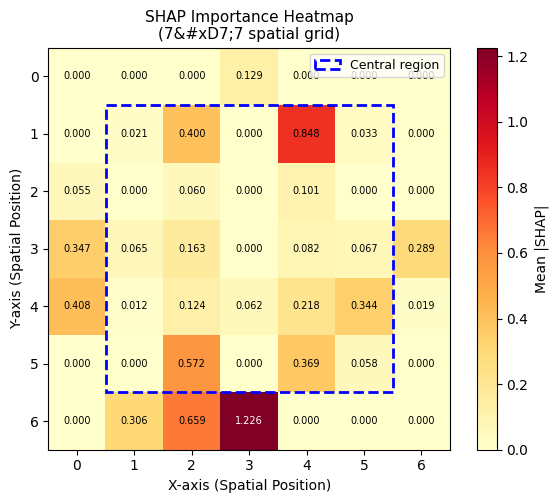


Saved: shap_zone_analysis.png

For your paper results section:
  Peripheral mean |SHAP| = 0.1432
  Central mean    |SHAP| = 0.1440
  Dominant zone          = Central


In [35]:
# ── Zone-level SHAP aggregation ──────────────────────────────────
# Uses shap_values and feature_names_49 already computed above
mean_abs_shap = np.abs(shap_values).mean(axis=0)  # (49,)

peri_indices = [i for i, name in enumerate(feature_names_49)
                if name.startswith('Peri')]
cent_indices = [i for i, name in enumerate(feature_names_49)
                if name.startswith('Cent')]

peri_shap_mean = mean_abs_shap[peri_indices].mean()
cent_shap_mean = mean_abs_shap[cent_indices].mean()

print("=" * 50)
print("SHAP Zone-Level Aggregation")
print("=" * 50)
print(f"Mean |SHAP| — Peripheral cells (n=24) : {peri_shap_mean:.4f}")
print(f"Mean |SHAP| — Central cells    (n=25) : {cent_shap_mean:.4f}")
dominant = "Peripheral" if peri_shap_mean > cent_shap_mean else "Central"
print(f"Dominant zone : {dominant}")

# Top 10 most important individual cells
ranked_idx = np.argsort(mean_abs_shap)[::-1]
print("\nTop 10 Most Important Grid Cells:")
print(f"{'Rank':<6} {'Cell':<12} {'Zone':<12} {'Mean |SHAP|':>12}")
print("-" * 44)
for rank, i in enumerate(ranked_idx[:10]):
    zone = 'Peripheral' if feature_names_49[i].startswith('Peri') else 'Central'
    print(f"{rank+1:<6} {feature_names_49[i]:<12} {zone:<12} "
          f"{mean_abs_shap[i]:>12.4f}")

# ── Figures ───────────────────────────────────
fig, axes = plt.subplots(1, 1, figsize=(6, 5))
# Right: 7x7 SHAP heatmap
shap_grid = mean_abs_shap.reshape(7, 7)
im = axes.imshow(shap_grid, cmap='YlOrRd')
axes.set_title('SHAP Importance Heatmap\n(7&#xD7;7 spatial grid)', fontsize=11)
axes.set_xlabel('X-axis (Spatial Position)')
axes.set_ylabel('Y-axis (Spatial Position)')
plt.colorbar(im, ax=axes, label='Mean |SHAP|')

for i in range(7):
    for j in range(7):
        axes.text(j, i, f'{shap_grid[i,j]:.3f}',
                     ha='center', va='center', fontsize=7,
                     color='black' if shap_grid[i,j] < shap_grid.max()*0.7
                     else 'white')

import matplotlib.patches as patches
rect = patches.Rectangle((0.5, 0.5), 5, 5,
                           linewidth=2, edgecolor='blue',
                           linestyle='--', facecolor='none',
                           label='Central region')
axes.add_patch(rect)
axes.legend(fontsize=9)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/shap_zone_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(f"\nSaved: shap_zone_analysis.png")
print(f"\nFor your paper results section:")
print(f"  Peripheral mean |SHAP| = {peri_shap_mean:.4f}")
print(f"  Central mean    |SHAP| = {cent_shap_mean:.4f}")
print(f"  Dominant zone          = {dominant}")